# The Planar Pendulum

The purpose of this notebook is to explore the application of ``DifferentialEquations.jl`` to models of the planar pendulum.

In [1]:
using Plots

In [2]:
using DifferentialEquations

The second order ODE 
$$
    \theta''(t) + \alpha \sin(\theta(t)) = 0
$$

is solved as a system of two coupled first order ODEs:

$$
    \theta'(t) = v(t)
$$

$$
         v'(t) = -\alpha \sin(\theta(t))
$$

with initial conditions $\theta(0) = \theta_0$, $v(0) = v_0$.

The parameter $\alpha$ equals $g/L$, where

* $g$ is the gravitational constant, and
* $L$ is the length of the pendulum.

## 1. defining the right hand side function

In [3]:
"""
    function pendrhs!(du, u, p, t)

defines the right hand side of the system
of first order differential equations of
a model of a planar pendulum.
The function updates the two components of du,
which respectively define the velocity and the acceleration,
while u[1] contains the value for the angle
and u[2] the value of the velocity.
The p is the array with the parameters
and t is the independent time variable.
"""
function pendrhs!(du, u, p, t)
    angle, velocity = u
    alpha = p
    du[1] = velocity          # instead of u[2]
    du[2] = -alpha*sin(angle) # angle is u[1]
end

pendrhs!

Next we define the initial conditions, in a 2-dimensional array, containing the initial angle and the initial velocity.

In [4]:
theta0 = pi/6  # initial angle

0.5235987755982988

In [5]:
v0 = 0 # initial velocity

0

In [6]:
initconds = [theta0, v0]

2-element Vector{Float64}:
 0.5235987755982988
 0.0

Then we have to define the time span, say from 0 to 10.

In [7]:
timespan = (0.0,10.0)

(0.0, 10.0)

For the parameter $\alpha$ we take the value equal to one.

In [8]:
alpha = 1.0

1.0

In [9]:
ode = ODEProblem(pendrhs!, initconds, timespan, alpha)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
Non-trivial mass matrix: false
timespan: (0.0, 10.0)
u0: 2-element Vector{Float64}:
 0.5235987755982988
 0.0

## 2. solving and plotting the solution

In [10]:
sol = solve(ode)

retcode: Success
Interpolation: 3rd order Hermite
t: 21-element Vector{Float64}:
  0.0
  0.0019961875625849126
  0.02195806318843404
  0.1184960439904155
  0.3126130215579742
  0.5861110333910544
  0.9374237545235629
  1.3728866886081446
  1.8504024235499985
  2.319596079644335
  2.9284343109627367
  3.571367701078837
  4.185654286923549
  4.938497147162857
  5.6335401765610325
  6.403054857703006
  7.178994232141367
  7.971364812133155
  8.794123004832556
  9.595349022947545
 10.0
u: 21-element Vector{Vector{Float64}}:
 [0.5235987755982988, 0.0]
 [0.523597779407389, -0.0009980932072375648]
 [0.5234782406579094, -0.010978267527158416]
 [0.5200920046456866, -0.05912794490220657]
 [0.49933935501726784, -0.1541018903952801]
 [0.43984530123710447, -0.27853954029656064]
 [0.31779570608764257, -0.4096366382545417]
 [0.11561729178611337, -0.5045757202926133]
 [-0.1292016993772076, -0.5012777488487357]
 [-0.34208628408690794, -0.38995230695701033]
 [-0.505755513017173, -0.1325316041869893]
 [-

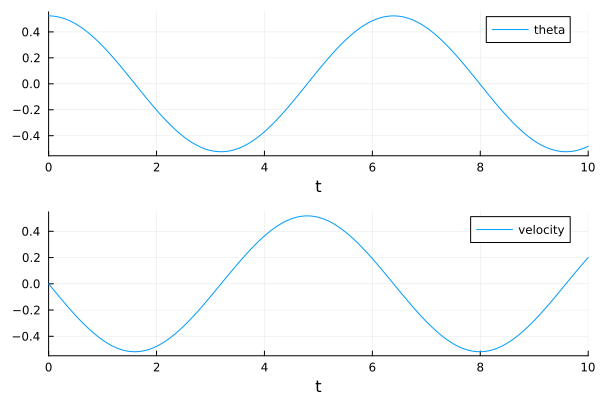

In [11]:
plot(sol, xaxis="t", label=["theta" "velocity"], layout=(2,1))

In [12]:
# savefig("figodependulum.png")